<a href="https://colab.research.google.com/github/avindumihisara0229-code/ErgoSense/blob/Avindu/Posture/TrainPosture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib
from google.colab import drive
from tqdm.notebook import tqdm



In [2]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Step 1: Setup complete. Libraries installed and Drive mounted.")

Mounted at /content/drive
✅ Step 1: Setup complete. Libraries installed and Drive mounted.


Define Paths

In [3]:
DATASET_PATH = '/content/drive/MyDrive/'

# Define the subfolders for correct and incorrect postures
correct_folders = [
    os.path.join(DATASET_PATH, 'old', '0'),
    os.path.join(DATASET_PATH, 'old', '2'),
    os.path.join(DATASET_PATH, 'old', '3')
]

incorrect_folders = [
    os.path.join(DATASET_PATH, 'old', 'bad', '0'),
    os.path.join(DATASET_PATH, 'old', 'bad', '2'),
    os.path.join(DATASET_PATH, 'old', 'bad', '3')
]

print("✅ Step 2: File paths are set.")

✅ Step 2: File paths are set.


Feature Extraction

In [4]:
mp_pose = mp.solutions.pose
# We must define the pose_model *before* the function that uses it.
pose_model = mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5, min_tracking_confidence=0.5)

def calculate_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    radians = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
    angle = np.abs(radians * 180.0 / np.pi)
    if angle > 180.0:
        angle = 360 - angle
    return angle

def extract_posture_landmarks_from_path(pose_estimator, image_path):
    image = cv2.imread(image_path)
    if image is None: return None

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = pose_estimator.process(image_rgb)

    if not results.pose_landmarks: return None

    landmarks = results.pose_landmarks.landmark
    try:
        left_shoulder = [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x, landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y]
        left_ear = [landmarks[mp_pose.PoseLandmark.LEFT_EAR.value].x, landmarks[mp_pose.PoseLandmark.LEFT_EAR.value].y]
        left_hip = [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x, landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y]
        left_knee = [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x, landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y]

        neck_angle = calculate_angle(left_ear, left_shoulder, left_hip)
        back_angle = calculate_angle(left_shoulder, left_hip, left_knee)

        return [neck_angle, back_angle]
    except:
        return None

print("✅ Step 3: Feature extraction logic defined.")

✅ Step 3: Feature extraction logic defined.


PROCESS THE DATASET

In [5]:
print("\n⏳ Starting feature extraction from posture image folders...")
features, labels = [], []
label_map = {"correct": 0, "incorrect": 1}


⏳ Starting feature extraction from posture image folders...


Correct Flders

In [6]:
print("Processing CORRECT posture folders...")
for folder_path in correct_folders:
    if not os.path.isdir(folder_path):
        print(f"⚠️ Warning: Folder '{folder_path}' not found. Skipping.")
        continue

    print(f"Processing subfolder: {folder_path}")
    for filename in tqdm(os.listdir(folder_path)):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_path = os.path.join(folder_path, filename)
            # Pass the initialized pose_model into the function
            landmarks = extract_posture_landmarks_from_path(pose_model, image_path)
            if landmarks:
                features.append(landmarks)
                labels.append(label_map["correct"]) # Append label 0

Processing CORRECT posture folders...
Processing subfolder: /content/drive/MyDrive/old/0


  0%|          | 0/146 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Processing subfolder: /content/drive/MyDrive/old/2


  0%|          | 0/145 [00:00<?, ?it/s]

Processing subfolder: /content/drive/MyDrive/old/3


  0%|          | 0/146 [00:00<?, ?it/s]

Incorrect Folder

In [7]:
print("\nProcessing INCORRECT posture folders...")
for folder_path in incorrect_folders:
    if not os.path.isdir(folder_path):
        print(f"⚠️ Warning: Folder '{folder_path}' not found. Skipping.")
        continue

    print(f"Processing subfolder: {folder_path}")
    for filename in tqdm(os.listdir(folder_path)):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_path = os.path.join(folder_path, filename)
            # Pass the initialized pose_model into the function
            landmarks = extract_posture_landmarks_from_path(pose_model, image_path)
            if landmarks:
                features.append(landmarks)
                labels.append(label_map["incorrect"]) # Append label 1

print(f"\n✅ Feature extraction complete. Processed {len(features)} images.")


Processing INCORRECT posture folders...
Processing subfolder: /content/drive/MyDrive/old/bad/0


  0%|          | 0/146 [00:00<?, ?it/s]

Processing subfolder: /content/drive/MyDrive/old/bad/2


  0%|          | 0/146 [00:00<?, ?it/s]

Processing subfolder: /content/drive/MyDrive/old/bad/3


  0%|          | 0/146 [00:00<?, ?it/s]


✅ Feature extraction complete. Processed 623 images.


THIS IS TO SAVE ECTARCTED DATA AS A CSV

In [8]:
print("\n⏳ Saving extracted features to CSV...")

# Create a DataFrame from the features and labels
feature_df = pd.DataFrame(features, columns=['neck_angle', 'back_angle'])
feature_df['label'] = labels # Add the labels (0 for correct, 1 for incorrect)

# Define the save path
CSV_SAVE_PATH = '/content/drive/MyDrive/posture_features.csv'

# Save the DataFrame to a CSV file
feature_df.to_csv(CSV_SAVE_PATH, index=False)

print(f"✅ Features saved successfully to: {CSV_SAVE_PATH}")
print("You can now open this CSV in Google Sheets or Excel.")


⏳ Saving extracted features to CSV...
✅ Features saved successfully to: /content/drive/MyDrive/posture_features.csv
You can now open this CSV in Google Sheets or Excel.


TRAIN

In [9]:
if len(features) < 10:
    print("\n❌ ERROR: Not enough data to train. Please check your DATASET_PATH and folder structure.")
else:
    X, y = np.array(features), np.array(labels)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    print("\n⏳ Training the Random Forest model for posture...")
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    print("✅ Model training complete!")

    y_pred = model.predict(X_test)
    print(f"\nModel Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
    print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["correct", "incorrect"]))

    MODEL_SAVE_PATH = '/content/drive/MyDrive/posture_model.joblib'
    joblib.dump(model, MODEL_SAVE_PATH)
    print(f"\n✅🎉 Model saved as 'posture_model.joblib' to your Google Drive!")



⏳ Training the Random Forest model for posture...
✅ Model training complete!

Model Accuracy: 77.60%

Classification Report:
               precision    recall  f1-score   support

     correct       0.76      0.78      0.77        60
   incorrect       0.79      0.77      0.78        65

    accuracy                           0.78       125
   macro avg       0.78      0.78      0.78       125
weighted avg       0.78      0.78      0.78       125


✅🎉 Model saved as 'posture_model.joblib' to your Google Drive!


In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import numpy as np


⏳ Training Random Forest...

📊 Generating Performance Visuals...


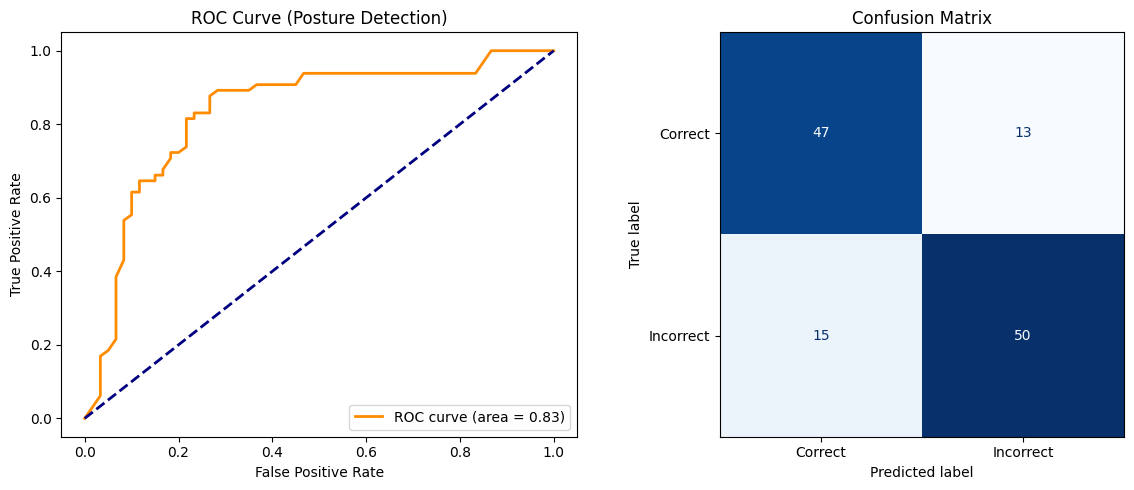

✅ Model saved to Google Drive.


In [12]:
from sklearn.metrics import RocCurveDisplay, precision_recall_curve

if len(features) >= 10:
    # 1. Prepare Data
    X, y = np.array(features), np.array(labels)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # 2. Train Model
    print("\n⏳ Training Random Forest...")
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

    # 3. GENERATE ROC CURVE
    print("\n📊 Generating Performance Visuals...")
    y_score = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(12, 5))

    # Subplot 1: ROC Curve
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (Posture Detection)')
    plt.legend(loc="lower right")

    # Subplot 2: Confusion Matrix (Replacing Loss Curve)
    plt.subplot(1, 2, 2)
    cm = confusion_matrix(y_test, model.predict(X_test))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Correct", "Incorrect"])
    disp.plot(ax=plt.gca(), cmap=plt.cm.Blues, colorbar=False)
    plt.title('Confusion Matrix')

    plt.tight_layout()
    plt.show()

    # 4. Final Save
    MODEL_SAVE_PATH = '/content/drive/MyDrive/posture_model.joblib'
    joblib.dump(model, MODEL_SAVE_PATH)
    print(f"✅ Model saved to Google Drive.")

Note on Loss Curves: Random Forest is an ensemble of trees and doesn't use "gradient descent" loss like a Neural Network. Instead, we visualize the Learning Curve or ROC Curve to show performance.